# Generación, limpieza y transformación de un DataSet el principio GIGO

Fecha: 28 de mayo del 2026

Autor: Maria Reina Zarate Nava

# Objetivo general
identificar problemas de calidad de datos,aplicar técnicas de limpieza y transformación,
y analizar cómo los datos incorrectos afectan el análisis y los modelos de Machine Learning mediante el principio GIGO.

# Actividad

Identifique y documente:

- Valores nulos
- Outliers (Negativos o fuera de rango)
- Datos inválidos
- Facturas canceladas ( identificadas con la letra c)
- Duplicados
- Problemas de formato o tipo de datos (Fechas o Monto)

Posteriormente:

- Limpie el dataset
- Transforme los datos
- Justifique las decisiones tomadas
- Explique cómo afecta el principio GIGO al análisis de datos y Machine Learning

# Graficas solicitadas para la identificación de anomalias
1. Ventas por pais
2. Heatmap de valores nulos
3. Distribución del monto

# Nota: 
Al terminar exportar el dataset limpio a formato csv y subir junto con el Laboratorio a GitHub, cumpliendo  con la siguiente estructura.

    - Notebooks (Folder)
        - Lab07.ipynb
    - DataSet (Folder)
        - Data_Limpio_Factura.csv

In [16]:
#importar las librerias
import pandas as pd

In [17]:
import numpy as np

In [21]:
import matplotlib.pyplot as plt

In [22]:
import seaborn as sns

In [6]:
#importar el data set
dfSucio = pd.read_csv("ventas-por-factura.csv")

In [7]:
dfSucio.shape

(25953, 6)

In [8]:
dfSucio.head()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [9]:
dfSucio.tail()

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"
25949,553060,5/13/2021 10:44:00,15826.0,United Kingdom,488,"720,00"
25950,577049,11/17/2021 13:58:00,17397.0,United Kingdom,104,"298,78"
25951,550122,4/14/2021 12:39:00,12931.0,United Kingdom,1176,"1488,00"
25952,537999,12/9/2020 11:44:00,NaN,United Kingdom,-223,"0,00"


In [10]:
#identificar los valores nulos
#existen valores nulos en monto, id cliente, datos negativos como en la cantidad y monto
#ver resumen
dfSucio.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [11]:
#antes que nada hay que hacer una copia por si el dataset se arruina o algo sale mal
dfCopy = dfSucio.copy()

In [12]:
dfSucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


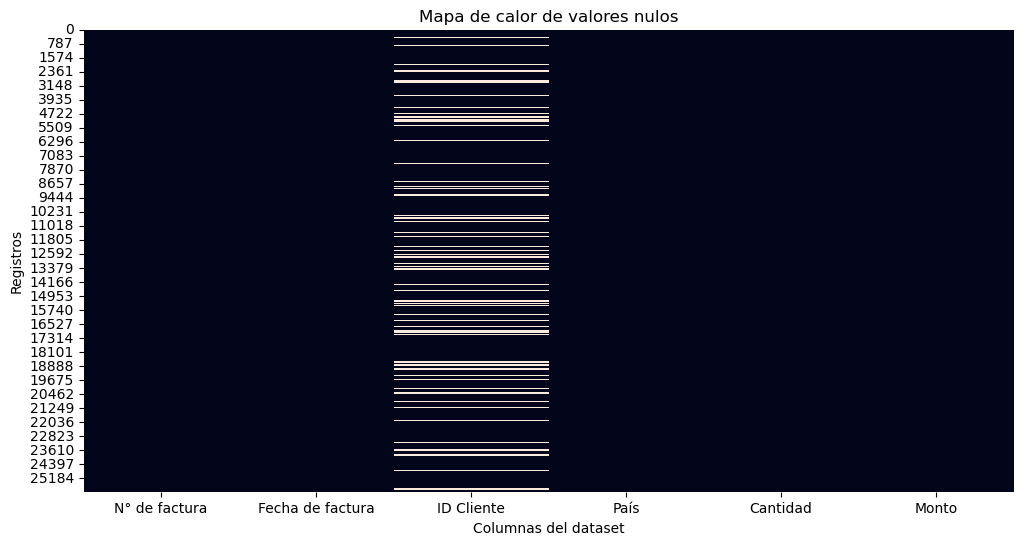

In [23]:
plt.figure(figsize=(12, 6))

sns.heatmap(dfSucio.isnull(), cbar=False)

plt.title("Mapa de calor de valores nulos")
plt.xlabel("Columnas del dataset")
plt.ylabel("Registros")
plt.show()

In [26]:
#Encontrar valores nulos
valores_nulos = dfSucio.isnull().sum()

In [25]:
valores_nulos

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [27]:
#Encontrar negativos o fuera de rango
outliers_cantidad = dfSucio[dfSucio["Cantidad"] < 0]

In [28]:
outliers_cantidad

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,"0,00"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"


In [33]:
datos_invalidos_cantidad = dfSucio[dfSucio["Cantidad"] <= 0]

In [34]:
datos_invalidos_cantidad

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,"0,00"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
...,...,...,...,...,...,...
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"
25948,C556518,6/13/2021 10:53:00,16794.0,United Kingdom,-2,"-12,70"


In [29]:
outliers_monto = dfSucio[dfSucio["Monto"].astype(str).str.contains("-", na=False)]

In [30]:
outliers_monto

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"
...,...,...,...,...,...,...
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,"-278,15"
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"


In [31]:
#paises vacios o nulos
datos_invalidos_pais = dfSucio[dfSucio["País"].isnull()]

In [32]:
datos_invalidos_pais

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [35]:
datos_invalidos_cliente = dfSucio[dfSucio["ID Cliente"].isnull()]

In [36]:
datos_invalidos_cliente

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
11,539736,12/21/2020 15:18:00,NaN,United Kingdom,143,"1172,46"
12,537823,12/8/2020 14:25:00,NaN,United Kingdom,1484,"6073,71"
16,542418,1/27/2021 17:39:00,NaN,United Kingdom,-17,"0,00"
21,550759,4/20/2021 12:09:00,NaN,United Kingdom,-7,"0,00"
23,556427,6/10/2021 13:23:00,NaN,United Kingdom,92,"435,69"
...,...,...,...,...,...,...
25930,539300,12/16/2020 17:31:00,NaN,United Kingdom,38,"72,59"
25932,565303,9/2/2021 12:17:00,NaN,Unspecified,258,"286,85"
25937,543533,2/9/2021 13:00:00,NaN,United Kingdom,155,"1001,27"
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,"-278,15"


In [37]:
#Facturas canceladas con la cuenta c
facturas_canceladas = dfSucio[
    dfSucio["N° de factura"].astype(str).str.startswith("C")
]

facturas_canceladas

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
10,C543628,2/10/2021 15:51:00,16558.0,United Kingdom,-5,"-9,25"
17,C553508,5/17/2021 13:44:00,14000.0,United Kingdom,-3,"-1,95"
20,C577693,11/21/2021 11:48:00,12628.0,Germany,-3,"-16,85"
22,C547309,3/22/2021 11:17:00,17416.0,United Kingdom,-12,"-45,00"
...,...,...,...,...,...,...
25939,C572450,10/24/2021 12:35:00,NaN,United Kingdom,-2,"-278,15"
25943,C557061,6/16/2021 14:55:00,14895.0,United Kingdom,-5,"-14,75"
25944,C562147,8/3/2021 10:47:00,16180.0,United Kingdom,-7,"-18,35"
25947,C553519,5/17/2021 14:16:00,18218.0,United Kingdom,-2,"-9,90"


In [38]:
facturas_canceladas.shape[0]

3841

In [40]:
#Convertir fecha de factura a formato de fecha
dfCopy["Fecha de factura"] = pd.to_datetime(
    dfCopy["Fecha de factura"],
    errors="coerce"
)

In [42]:
#Fechas invalidas
fechas_invalidas = dfCopy[dfCopy["Fecha de factura"].isnull()]

In [43]:
fechas_invalidas

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [44]:
#Convertir monto
dfCopy["Monto"] = (
    dfCopy["Monto"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

dfCopy["Monto"] = pd.to_numeric(dfCopy["Monto"], errors="coerce")

In [45]:
montos_invalidos = dfCopy[dfCopy["Monto"].isnull()]

In [46]:
montos_invalidos

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto


In [47]:
#Convertir monto a numerica
dfGraficas = dfSucio.copy()

dfGraficas["Monto"] = (
    dfGraficas["Monto"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

dfGraficas["Monto"] = pd.to_numeric(dfGraficas["Monto"], errors="coerce")

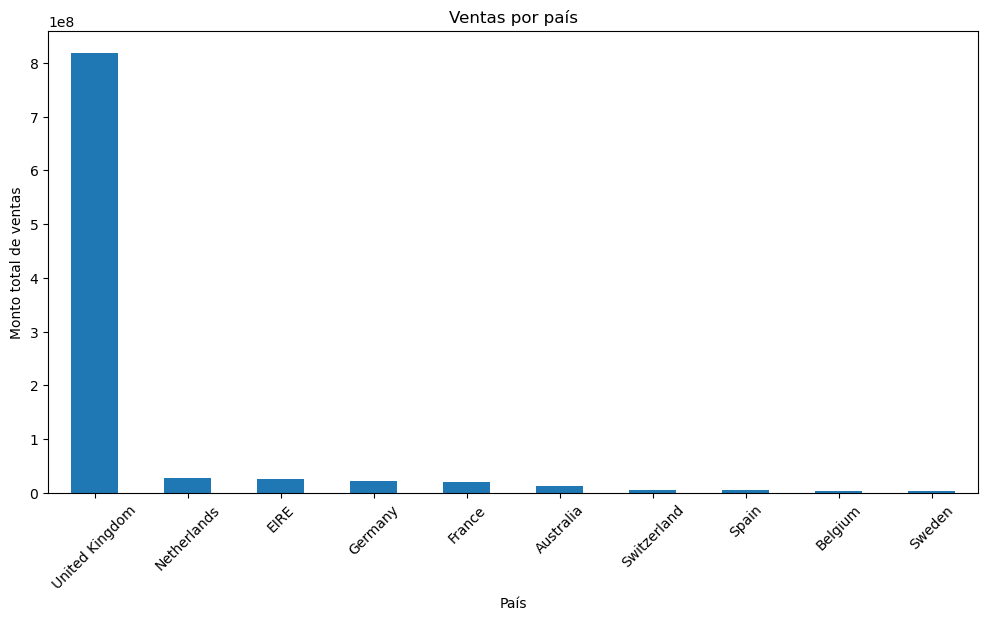

In [48]:
#grafica de ventas
ventas_pais = dfGraficas.groupby("País")["Monto"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

ventas_pais.plot(kind="bar")

plt.title("Ventas por país")
plt.xlabel("País")
plt.ylabel("Monto total de ventas")
plt.xticks(rotation=45)

plt.show()

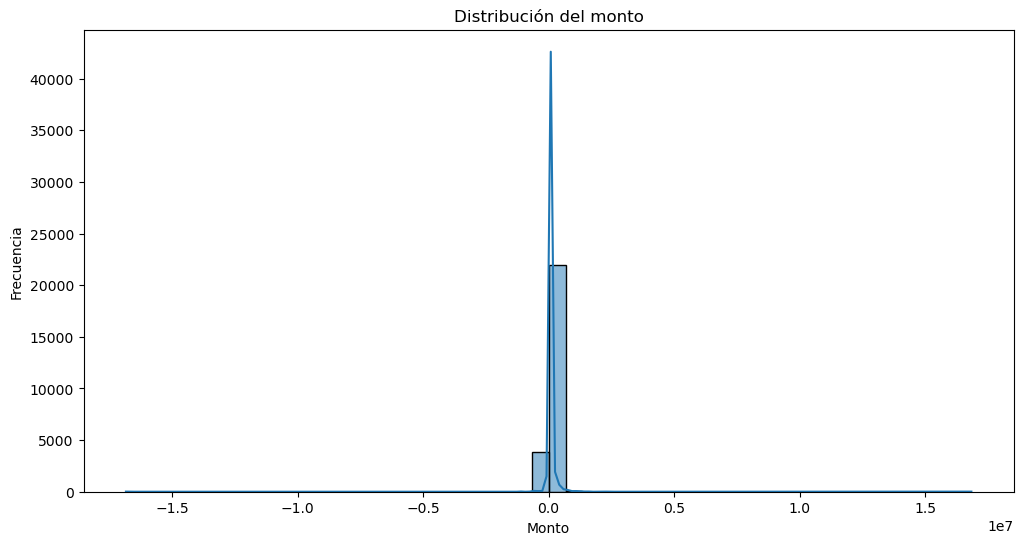

In [49]:
#Grafica de montos
plt.figure(figsize=(12, 6))

sns.histplot(dfGraficas["Monto"], bins=50, kde=True)

plt.title("Distribución del monto")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")

plt.show()

In [50]:
dfLimpio = dfSucio.copy()

In [51]:
#limpieza del database
dfLimpio["Fecha de factura"] = pd.to_datetime(
    dfLimpio["Fecha de factura"], 
    errors="coerce"
)

dfLimpio["Monto"] = (
    dfLimpio["Monto"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

dfLimpio["Monto"] = pd.to_numeric(dfLimpio["Monto"], errors="coerce")

dfLimpio = dfLimpio[
    ~dfLimpio["N° de factura"].astype(str).str.startswith("C")
]

dfLimpio = dfLimpio.drop_duplicates()

dfLimpio = dfLimpio[dfLimpio["Cantidad"] > 0]
dfLimpio = dfLimpio[dfLimpio["Monto"] > 0]

dfLimpio = dfLimpio.dropna(subset=["Fecha de factura"])

dfLimpio["ID Cliente"] = dfLimpio["ID Cliente"].fillna("Sin identificar")

In [52]:
dfLimpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20002 entries, 0 to 25951
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   N° de factura     20002 non-null  object        
 1   Fecha de factura  20002 non-null  datetime64[ns]
 2   ID Cliente        20002 non-null  object        
 3   País              20002 non-null  object        
 4   Cantidad          20002 non-null  int64         
 5   Monto             20002 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 1.1+ MB


In [53]:
dfLimpio.isnull().sum()

N° de factura       0
Fecha de factura    0
ID Cliente          0
País                0
Cantidad            0
Monto               0
dtype: int64

In [54]:
dfLimpio.to_csv("dataset_limpio.csv", index=False, encoding="utf-8-sig")

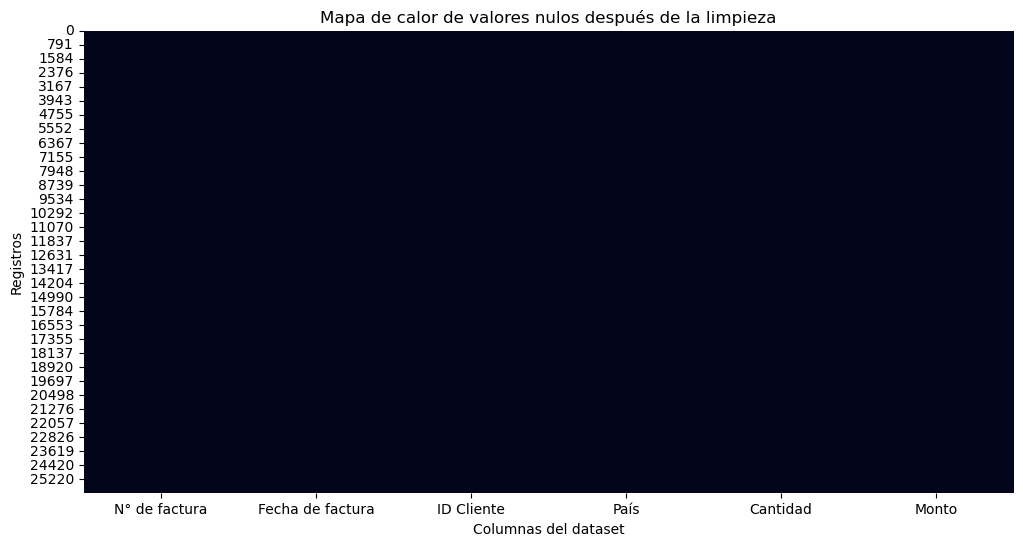

In [55]:
plt.figure(figsize=(12, 6))

sns.heatmap(dfLimpio.isnull(), cbar=False)

plt.title("Mapa de calor de valores nulos después de la limpieza")
plt.xlabel("Columnas del dataset")
plt.ylabel("Registros")

plt.show()

# CONCLUSIONES
1. Se hizo un mapa de calor para identificar los valores nulos del dataset. 
2. Se identifico que la columna "ID Cliente" tiene datos faltantes.
3. Se identificó que la columna "Fecha de factura" tiene tipo object, y debe convertirse a 
formato fecha al igual que la columna "Monto" debería ser numérica.

CONCLUSION DEL TRABAJO

En esta práctica se realizó un proceso de identificación, análisis y limpieza de datos 
aplicando el principio GIGO (Garbage In, Garbage Out), el cual indica que si los datos 
de entrada son incorrectos, incompletos o desordenados, los resultados del análisis también 
serán poco confiables.

Primero se exploró el dataset utilizando comandos como dfSucio.info(), lo que permitió 
conocer la cantidad de registros, columnas, tipos de datos y valores no nulos. A partir 
de esta revisión se identificó que la columna ID Cliente presentaba valores faltantes, 
ya que solo contaba con 22,229 registros no nulos de un total de 25,953 registros.

Posteriormente, se utilizaron gráficas para visualizar mejor las anomalías del dataset. 
El mapa de calor de valores nulos permitió observar de forma clara que los datos faltantes 
se concentran principalmente en la columna ID Cliente. Además, la gráfica de ventas por país 
permitió identificar los países con mayor concentración de ventas, mientras que la distribución 
del monto ayudó a observar el comportamiento de los valores monetarios y detectar posibles datos 
atípicos.

Por lo tanto, la limpieza y transformación del dataset es una etapa fundamental para asegurar 
que la información sea más confiable, ordenada y útil para obtener conclusiones válidas.